# BO baseline: running average yield

Reads `bo_metrics.csv` and plots, per function evaluation:
- the per-batch `yield` (scatter), and
- a dashed line for the **average yield so far** = the cumulative mean of all yields up to and including that evaluation.

Plotting mimics the convergence plot in `experiments/01_bo_baseline.py`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RECIPE_MEAN_YIELD = 1513.48  # recipe baseline, same value used in 01_bo_baseline.py

df = pd.read_csv("bo_metrics.csv")
yields = df["yield"].values

# average yield so far: cumulative mean over all previous (and current) evaluations
running_avg = np.cumsum(yields) / np.arange(1, len(yields) + 1)
print(f"{len(yields)} evaluations, final running average = {running_avg[-1]:.1f}")

1000 evaluations, final running average = 1562.0


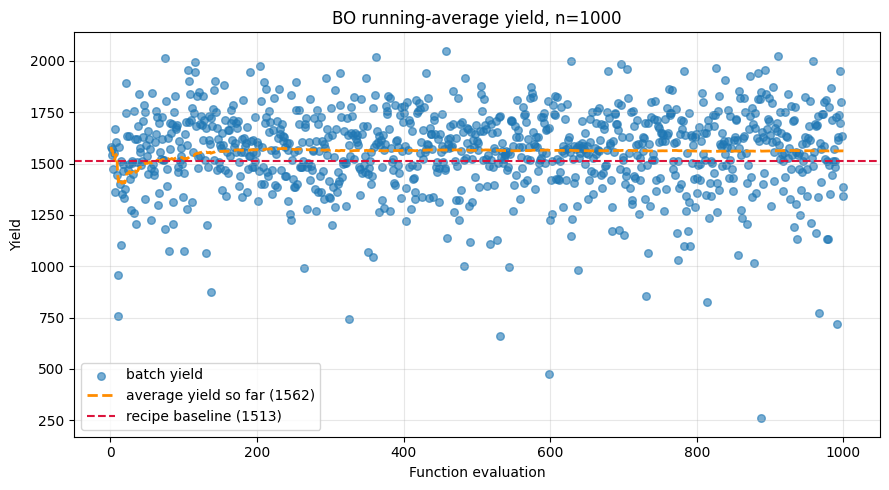

In [2]:
x = range(1, len(yields) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, yields, s=30, alpha=.6, label="batch yield")
ax.plot(x, running_avg, color="darkorange", lw=2, ls="--",
        label=f"average yield so far ({running_avg[-1]:.0f})")
ax.axhline(RECIPE_MEAN_YIELD, color="crimson", ls="--",
           label=f"recipe baseline ({RECIPE_MEAN_YIELD:.0f})")
ax.set_xlabel("Function evaluation")
ax.set_ylabel("Yield")
ax.set_title(f"BO running-average yield, n={len(yields)}")
ax.legend()
ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig("bo_running_average.png", dpi=150)
plt.show()